# SOH Forecasting — Multi-cell training, held-out Cell_23

Same pipeline and corrected SOH formula as `soh_forecast_dqdv_nasa_corrected_vehicle_features.ipynb`, but trained on **three cells combined** (Cell_14, Cell_21, Cell_25) and tested on **Cell_23**.

## Key design choices

- **Sample-level scaling (global, same constants for all cells):**

```python
Voltage_Scaled = (VOLTAGE - 3.622) / (4.31 - 3.622)
Current_Scaled = CURRENT / 2.01
```

  Applied to raw 8-second samples before segment aggregation. The scaler constants are identical across cells so the model sees the same scale everywhere.

- **Per-cell SOH parameters:**

| Cell | α | w_cc | w_cv | role |
|------|---|------|------|------|
| 14   | 0.8 | 0.6 | 0.4 | train |
| 21   | 1.0 | 0.6 | 0.4 | train |
| 25   | 0.6 | 0.6 | 0.4 | train |
| 23   | 0.8 | 0.6 | 0.4 | **test (held out)** |

  Each cell's `Q_cc_avg`, `Q_cv_avg`, `ΔV_avg` come from that cell's own first 10 segments.

- **No `cell_id` feature.** The model has to be cell-agnostic to generalise to Cell_23.
- **Windows do not cross cell boundaries.** Built per cell, then concatenated for training.
- **Test starts at Cell_23 segment 30.** The first 30 segments of Cell_23 serve as the input window for the first prediction (segment 30), then we predict every segment 30..N-1.
- **Validation:** 10 % of training windows, shuffled across cells.

> Requires: `pandas numpy matplotlib scikit-learn torch`


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 1. Configuration

In [2]:
# Per-cell configuration. Path is relative to this notebook's working directory.
CELL_CONFIG = {
    14: {"path": "Cell_14_NASA.csv", "alpha": 0.8, "w_cc": 0.6, "role": "train"},
    21: {"path": "Cell_21_NASA.csv", "alpha": 1.0, "w_cc": 0.6, "role": "train"},
    25: {"path": "Cell_25_NASA.csv", "alpha": 0.6, "w_cc": 0.6, "role": "train"},
    23: {"path": "Cell_23_NASA.csv", "alpha": 0.8, "w_cc": 0.6, "role": "test"},
}

# Sample-level scaling constants (same for every cell)
V_MIN_SCALE = 3.622
V_MAX_SCALE = 4.31
I_SCALE     = 2.01

# CC/CV split, aggregation, SOH derivation, model knobs
V_CV         = 4.199
MIN_ROWS     = 10
REF_HEAD     = 10
ROLL_WINDOW  = 5
WINDOW       = 30
HORIZON      = 1


## 2. Load + aggregate each cell

Per-segment aggregation with CC/CV split. Voltage and current are scaled at the **sample** level using the global constants; the SOH formula still uses raw `q_cc`, `dv_cc`, `q_cv` so the per-cell SOH calibration is unchanged. Only the *input features* see the scaled values.


In [ ]:
def load_and_aggregate(cell_id, path):
    df = pd.read_csv(path)
    if df.columns[0].startswith("Unnamed"):
        df = df.drop(columns=df.columns[0])

    # Sample-level scaling (global, same across cells)
    df["Voltage_Scaled"] = (df["VOLTAGE"] - V_MIN_SCALE) / (V_MAX_SCALE - V_MIN_SCALE)
    df["Current_Scaled"] = df["CURRENT"] / I_SCALE

    def agg(g, sid):
        if len(g) < MIN_ROWS:
            return None
        voltage = g["VOLTAGE"].values
        v_scaled = g["Voltage_Scaled"].values
        current = g["CURRENT"].values
        i_scaled = g["Current_Scaled"].values
        q_vals  = g["Q"].values

        # CC/CV split on raw voltage
        above = np.where(voltage >= V_CV)[0]
        if len(above) > 0:
            trans = above[0]
            if trans > 0:
                q_cc  = float(q_vals[trans-1] - q_vals[0])
                dv_cc = float(voltage[trans-1] - voltage[0])
                q_cv  = float(q_vals[-1]      - q_vals[trans-1])
            else:
                q_cc, dv_cc = 0.0, 0.0
                q_cv = float(q_vals[-1] - q_vals[0])
        else:
            q_cc  = float(q_vals[-1]  - q_vals[0])
            dv_cc = float(voltage[-1] - voltage[0])
            q_cv  = 0.0

        return pd.Series({
            "Original_Segment":   int(sid),
            "segment_id":         int(sid),
            "t_start":            float(g["TIME"].iloc[0]),
            "t_end":              float(g["TIME"].iloc[-1]),
            "date_end":           g["DATE"].iloc[-1],
            "duration_min":       (g["TIME"].iloc[-1] - g["TIME"].iloc[0]) / 60.0,
            "delta_v":            float(voltage[-1] - voltage[0]),
            # Scaled aggregates used as model features
            "v_mean_scaled":      float(v_scaled.mean()),
            "v_max_scaled":       float(v_scaled.max()),
            "v_min_scaled":       float(v_scaled.min()),
            "delta_v_scaled":     float(v_scaled[-1] - v_scaled[0]),
            "i_mean_abs_scaled":  float(np.abs(i_scaled).mean()),
            "i_max_abs_scaled":   float(np.abs(i_scaled).max()),
            # Other aggregates
            "temp_max":           float(g["TEMPERATURE"].max()),
            "temp_min":           float(g["TEMPERATURE"].min()),
            "temp_spread":        float(g["TEMPERATURE"].max() - g["TEMPERATURE"].min()),
            "cap_charged_ah":     float(q_vals[-1] - q_vals[0]),
            "q_max":              float(q_vals.max()),
            "energy_wh":          float(g["Energy_Wh"].iloc[-1] - g["Energy_Wh"].iloc[0]),
            "n_samples":          len(g),
            # For the SOH formula
            "q_cc":               q_cc,
            "dv_cc":              dv_cc,
            "q_cv":               q_cv,
        })

    records = []
    for sid, g in df.groupby("Original_Segment", sort=True):
        rec = agg(g, sid)
        if rec is not None:
            records.append(rec)

    cycles = pd.DataFrame(records).reset_index(drop=True)
    cycles["cell_id"] = cell_id
    cycles["cycle_idx"] = np.arange(len(cycles))
    cycles["days_since_start"] = (cycles["t_start"] - cycles["t_start"].iloc[0]) / 86400.0
    return cycles


## 3. Per-cell SOH derivation

Each cell's references (`Q_cc_avg`, `Q_cv_avg`, `ΔV_avg`) and parameters (`α`, `w_cc`) come from its own config. SOH is smoothed with a 5-segment rolling median before being used as a feature/target.


In [4]:
def compute_soh(cycles, alpha, w_cc, ref_head=REF_HEAD, roll_window=ROLL_WINDOW):
    w_cv = 1.0 - w_cc
    Q_cc_avg    = cycles["q_cc"].head(ref_head).mean()
    Q_cv_avg    = cycles["q_cv"].head(ref_head).mean()
    DeltaV_avg  = cycles["dv_cc"].head(ref_head).mean()

    cycles = cycles.copy()
    cycles["K_cc_corr1"] = DeltaV_avg / cycles["dv_cc"]
    cycles["Q_cc_corr"]  = cycles["K_cc_corr1"].pow(alpha)
    cycles["soh_cc_corr"] = cycles["Q_cc_corr"] * (cycles["q_cc"] / Q_cc_avg)
    cycles["soh_cv_corr"] = cycles["q_cv"] / Q_cv_avg
    cycles["soh_pct_raw"] = (cycles["soh_cc_corr"] * w_cc + cycles["soh_cv_corr"] * w_cv) * 100.0

    cycles = cycles[np.isfinite(cycles["soh_pct_raw"])].reset_index(drop=True)
    cycles["cycle_idx"] = np.arange(len(cycles))

    cycles["soh_pct"] = (
        cycles["soh_pct_raw"]
        .rolling(roll_window, min_periods=1, center=True)
        .median()
    )
    refs = {"Q_cc_avg": Q_cc_avg, "Q_cv_avg": Q_cv_avg, "DeltaV_avg": DeltaV_avg,
            "alpha": alpha, "w_cc": w_cc}
    return cycles, refs


## 4. Run aggregation + SOH for all four cells

In [5]:
all_cycles = {}
all_refs   = {}
for cell_id, cfg in CELL_CONFIG.items():
    cyc = load_and_aggregate(cell_id, cfg["path"])
    cyc, refs = compute_soh(cyc, cfg["alpha"], cfg["w_cc"])
    all_cycles[cell_id] = cyc
    all_refs[cell_id]   = refs
    print(f"Cell {cell_id} ({cfg['role']:5s}): {len(cyc):4d} segments  "
          f"alpha={cfg['alpha']}  w_cc={cfg['w_cc']}  "
          f"Q_cc_avg={refs['Q_cc_avg']:.4f}  Q_cv_avg={refs['Q_cv_avg']:.4f}  "
          f"DeltaV_avg={refs['DeltaV_avg']:.4f}")


Cell 14 (train):  387 segments  alpha=0.8  w_cc=0.6  Q_cc_avg=1.2134  Q_cv_avg=0.7017  DeltaV_avg=0.3757
Cell 21 (train):  491 segments  alpha=1.0  w_cc=0.6  Q_cc_avg=1.1034  Q_cv_avg=0.7716  DeltaV_avg=0.3261
Cell 25 (train):  448 segments  alpha=0.6  w_cc=0.6  Q_cc_avg=0.3500  Q_cv_avg=0.8122  DeltaV_avg=0.1403
Cell 23 (test ):  479 segments  alpha=0.8  w_cc=0.6  Q_cc_avg=1.0067  Q_cv_avg=0.7680  DeltaV_avg=0.2976


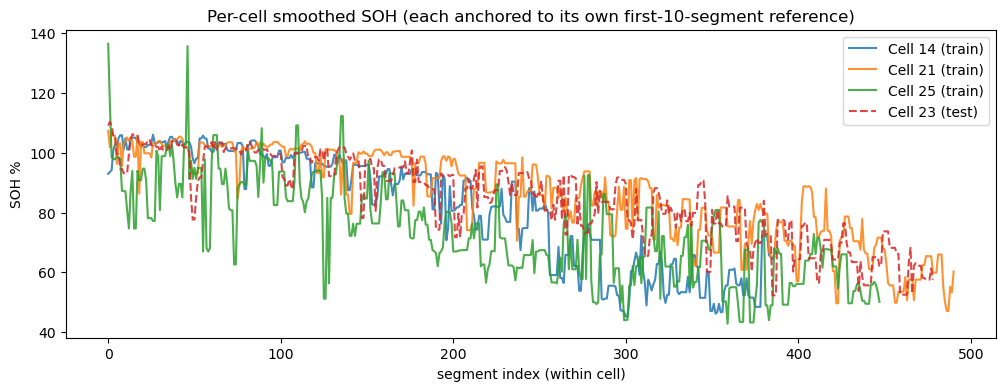

In [6]:
# Quick look at the per-cell SOH curves
fig, ax = plt.subplots(figsize=(12, 4))
for cid, cyc in all_cycles.items():
    role = CELL_CONFIG[cid]["role"]
    ls = "-" if role == "train" else "--"
    ax.plot(cyc["cycle_idx"], cyc["soh_pct"], ls, alpha=0.85, label=f"Cell {cid} ({role})")
ax.set_xlabel("segment index (within cell)"); ax.set_ylabel("SOH %"); ax.legend()
ax.set_title("Per-cell smoothed SOH (each anchored to its own first-10-segment reference)")
plt.show()


## 5. Build windows per cell, combine training, separate test

Windows do not cross cell boundaries. For each cell, `make_windows` builds (X, y) pairs where the input is 30 consecutive segments and the target is the SOH of the next segment.


In [7]:
FEATURE_COLS = [
    "duration_min",
    "v_mean_scaled", "v_max_scaled", "v_min_scaled", "delta_v_scaled",
    "i_mean_abs_scaled", "i_max_abs_scaled",
    "temp_max", "temp_min", "temp_spread",
    "cap_charged_ah", "energy_wh",
    "q_max",
    "days_since_start",
    "soh_pct",     # current SOH as input feature for next-segment forecast
]
print("Features:", len(FEATURE_COLS))

def make_windows(cyc, window=WINDOW, horizon=HORIZON):
    X = cyc[FEATURE_COLS].values.astype(np.float32)
    y = cyc["soh_pct"].values.astype(np.float32)
    Xs, ys = [], []
    for i in range(len(cyc) - window - horizon + 1):
        Xs.append(X[i:i+window])
        ys.append(y[i + window + horizon - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# Training windows from cells 14, 21, 25
train_X_blocks, train_y_blocks = [], []
for cid, cfg in CELL_CONFIG.items():
    if cfg["role"] != "train": continue
    Xc, yc = make_windows(all_cycles[cid])
    train_X_blocks.append(Xc); train_y_blocks.append(yc)
    print(f"  Cell {cid:2d}: {len(Xc)} windows")
X_train_all = np.concatenate(train_X_blocks, axis=0)
y_train_all = np.concatenate(train_y_blocks, axis=0)
print(f"Combined train: X {X_train_all.shape}  y {y_train_all.shape}")

# Test windows from Cell 23 (test-cycle indices = 30, 31, ..., N-1)
cell_test = all_cycles[23]
X_test, y_test = make_windows(cell_test)
test_cycle_idx = np.arange(WINDOW + HORIZON - 1, len(cell_test))
print(f"Test (Cell 23): {len(X_test)} windows, predicting cycle_idx {test_cycle_idx[0]}..{test_cycle_idx[-1]}")


Features: 15
  Cell 14: 357 windows
  Cell 21: 461 windows
  Cell 25: 418 windows
Combined train: X (1236, 30, 15)  y (1236,)
Test (Cell 23): 449 windows, predicting cycle_idx 30..478


In [8]:
# StandardScaler fit on training feature rows only, applied to both train and test
scaler = StandardScaler().fit(X_train_all.reshape(-1, X_train_all.shape[-1]))
def scale(X):
    flat = X.reshape(-1, X.shape[-1])
    return scaler.transform(flat).reshape(X.shape).astype(np.float32)

X_train_all = scale(X_train_all)
X_test      = scale(X_test)
print("Scaled.")


Scaled.


In [9]:
# Shuffle training windows across cells, carve a 10% validation slice
rng = np.random.RandomState(0)
idx = rng.permutation(len(X_train_all))
val_n = max(64, int(0.1 * len(X_train_all)))
val_idx   = idx[:val_n]
train_idx = idx[val_n:]
X_tr, y_tr = X_train_all[train_idx], y_train_all[train_idx]
X_vl, y_vl = X_train_all[val_idx],   y_train_all[val_idx]
print(f"train {len(X_tr)}  val {len(X_vl)}  test {len(X_test)}")

class WinDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X); self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_dl = DataLoader(WinDS(X_tr, y_tr),     batch_size=64, shuffle=True)
val_dl   = DataLoader(WinDS(X_vl, y_vl),     batch_size=128)
test_dl  = DataLoader(WinDS(X_test, y_test), batch_size=128)


train 1113  val 123  test 449


## 6. Transformer encoder model

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class SOHTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, layers=3, dim_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos = PositionalEncoding(d_model)
        enc = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(enc, num_layers=layers)
        self.head = nn.Sequential(nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, 1))
    def forward(self, x):
        h = self.pos(self.input_proj(x)); h = self.encoder(h)
        return self.head(h[:, -1]).squeeze(-1)

model = SOHTransformer(n_features=len(FEATURE_COLS)).to(DEVICE)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable params: 105665


## 7. Train

epoch   0  train 6324.39025  val 6250.65039  best 6250.65039
epoch   5  train 2654.89566  val 2210.34619  best 2210.34619
epoch  10  train 96.99188  val 57.60565  best 57.60565
epoch  15  train 67.35389  val 48.74226  best 46.13374
epoch  20  train 62.33075  val 49.62206  best 45.40229
epoch  25  train 59.15559  val 53.31423  best 45.40229
epoch  30  train 54.89337  val 43.86835  best 43.86835
epoch  35  train 54.72657  val 50.62687  best 43.86835
epoch  40  train 48.15149  val 50.71307  best 43.86835
Early stop at epoch 42, best val 43.86835


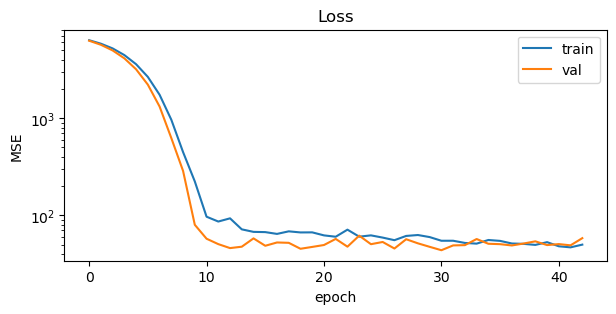

In [11]:
EPOCHS = 80
LR = 1e-3
PATIENCE = 12

opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.MSELoss()

best_val = float("inf"); best_state = None; bad = 0
hist = {"train": [], "val": []}

for epoch in range(EPOCHS):
    model.train(); tr = 0.0; n = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tr += loss.item() * len(xb); n += len(xb)
    sched.step(); tr /= n

    model.eval(); vl = 0.0; nv = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl += loss_fn(model(xb), yb).item() * len(xb); nv += len(xb)
    vl /= nv
    hist["train"].append(tr); hist["val"].append(vl)

    if vl < best_val - 1e-6:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d}  train {tr:.5f}  val {vl:.5f}  best {best_val:.5f}")
    if bad >= PATIENCE:
        print(f"Early stop at epoch {epoch}, best val {best_val:.5f}")
        break

model.load_state_dict(best_state)

plt.figure(figsize=(7, 3))
plt.plot(hist["train"], label="train"); plt.plot(hist["val"], label="val")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("Loss")
plt.show()


## 8. Evaluate on Cell_23

Forecast every segment from cycle_idx 30 onwards using teacher-forced rolling 30-segment windows.


In [12]:
@torch.no_grad()
def predict(model, dl):
    model.eval()
    out = []
    for xb, _ in dl:
        out.append(model(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

y_pred = predict(model, test_dl)

# Persistence: last SOH in each test window (unscaled back)
soh_idx = FEATURE_COLS.index("soh_pct")
mu, sg  = scaler.mean_[soh_idx], scaler.scale_[soh_idx]
y_persist = X_test[:, -1, soh_idx] * sg + mu

# Linear extrapolation fit on training cells' SOH vs days_since_start? Use a simple per-test-cycle linear
# baseline on Cell_23's own training-region SOH (first 30 segments, then extrapolate)
warmup = cell_test["soh_pct"].values[:WINDOW]
coef = np.polyfit(np.arange(WINDOW), warmup, 1)
y_linear = np.polyval(coef, test_cycle_idx)

def report(name, yt, yp):
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    print(f"{name:14s}  MAE {mean_absolute_error(yt, yp):.4f}  RMSE {rmse:.4f}  R2 {r2_score(yt, yp):.4f}")

report("Transformer", y_test, y_pred)
# report("Persistence", y_test, y_persist)
# report("Linear (Cell_23 warmup)", y_test, y_linear)


Transformer     MAE 4.0117  RMSE 5.6598  R2 0.8328


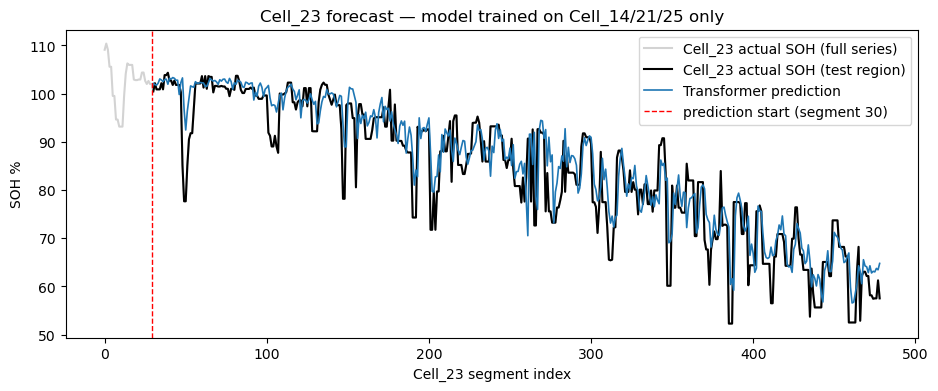

In [13]:
plt.figure(figsize=(11, 4))
plt.plot(cell_test["cycle_idx"], cell_test["soh_pct"], color="lightgray", label="Cell_23 actual SOH (full series)")
plt.plot(test_cycle_idx, y_test,    "k",     lw=1.5, label="Cell_23 actual SOH (test region)")
plt.plot(test_cycle_idx, y_pred,    "C0",    lw=1.2, label="Transformer prediction")
# plt.plot(test_cycle_idx, y_linear,  "C2--",  lw=1.0, label="Linear (Cell_23 warmup)")
# plt.plot(test_cycle_idx, y_persist, "C3:",   lw=1.0, label="Persistence")
plt.axvline(WINDOW - 1, color="red", ls="--", lw=1, label="prediction start (segment 30)")
plt.xlabel("Cell_23 segment index"); plt.ylabel("SOH %")
plt.title("Cell_23 forecast — model trained on Cell_14/21/25 only")
plt.legend()
plt.show()


## 9. Results dataframe (actual vs predicted SOH for Cell_23)

Per-test-segment dataframe with `segment_id`, `cycle_idx`, end timestamp (seconds and wall-clock), actual smoothed SOH, predicted SOH, and absolute error.


In [ ]:
test_rows = cell_test.loc[test_cycle_idx].reset_index(drop=True)
results_df = pd.DataFrame({
    "cycle_idx":        test_cycle_idx,
    "Original_Segment": test_rows["Original_Segment"].astype(int).values,
    "segment_id":       test_rows["segment_id"].astype(int).values,
    "t_end_s":          test_rows["t_end"].values,
    "date_end":         test_rows["date_end"].values,
    "soh_actual":       y_test,
    "soh_predicted":    y_pred,
})
results_df["abs_error"] = (results_df["soh_actual"] - results_df["soh_predicted"]).abs()
print(f"{len(results_df)} test rows  |  MAE = {results_df['abs_error'].mean():.3f}")
results_df.head()


In [15]:
results_df.to_csv("cell_23_multicell_SOH_actual_predicted.csv")

## 10. Export to CSV

- `cell_23_multicell_actual_predicted.csv` — the actual-vs-predicted table for Cell_23 test segments only.
- `nasa_multicell_all_actual_soh.csv` — actual smoothed SOH for **all four cells**, every segment (including training-cell segments and Cell_23 warmup).


In [ ]:
# results_df.to_csv("cell_23_multicell_actual_predicted.csv", index=False)
print(f"Wrote cell_23_multicell_actual_predicted.csv  ({len(results_df)} rows)")

all_actual_blocks = []
for cid, cyc in all_cycles.items():
    block = cyc[["cell_id", "cycle_idx", "Original_Segment", "segment_id", "t_end", "date_end", "soh_pct_raw", "soh_pct"]].copy()
    block = block.rename(columns={"t_end": "t_end_s", "soh_pct": "soh_actual_smoothed", "soh_pct_raw": "soh_actual_raw"})
    block["Original_Segment"] = block["Original_Segment"].astype(int)
    block["segment_id"] = block["segment_id"].astype(int)
    block["role"] = CELL_CONFIG[cid]["role"]
    all_actual_blocks.append(block)
all_actual_df = pd.concat(all_actual_blocks, ignore_index=True)
# all_actual_df.to_csv("nasa_multicell_all_actual_soh.csv", index=False)
print(f"Wrote nasa_multicell_all_actual_soh.csv  ({len(all_actual_df)} rows across {len(all_cycles)} cells)")
all_actual_df.head()


## Notes & next steps

- **Per-cell parameters** drive the SOH calibration of each cell. To re-tune Cell_23 specifically, edit `CELL_CONFIG[23]` and re-run from step 4 onward — training doesn't need to be repeated.
- **Sample-level V/I scaling** is global: change `V_MIN_SCALE`, `V_MAX_SCALE`, `I_SCALE` at the top to match a different cell family.
- **No `cell_id` feature** means the model has to generalise — but if you want to allow it, add a one-hot or scalar `cell_id` to `FEATURE_COLS` and to the per-cell aggregator. Cell_23 will need a "novel" embedding strategy at inference.
- **Validation is shuffled across training cells.** This rewards the model for being cell-agnostic. If you want a stricter holdout, switch the validation slice to the *last 10% of each training cell* (chronological) instead of a random shuffle.
- **Persistence and linear baselines** are computed inside the notebook so you can see whether the Transformer's MAE on Cell_23 is genuinely better than naive forecasts trained from Cell_23 alone.
